# MoE-Only Darcy Experiments

This notebook repeats the reference experiments from `hard_dirichlet.ipynb` and `hard_dirichlet_half_square.ipynb`,
while training and evaluating only a single MoE (expert) model for each problem.


In [80]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import os
import sys
import copy
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau

sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.mlp_model as mm
import src.models.expert_chars as ec
from src.calculus import L2_norm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

os.makedirs('./images_moe_only_double', exist_ok=True)
print(f'Using device: {device}')


Using device: cuda


## Problem 1: Circular Interface (from hard_dirichlet)

We solve the same circular-discontinuity problem and train only `model_combined_exp`.


In [82]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)

def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)

def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2

def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)

def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    res_1 = k(pde_in) * grad_u + v
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]
    res_2 = v_1_x + v_2_y
    return res_1, res_2


In [83]:
def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).float().unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[64, 64, 64],
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[lambda x: 1 - chi(x), chi],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[32, 32, 32], [32, 32, 32]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_u_exp = mm.MLPModel(model_ctx_u).to(device)
model_v_exp = ec.PerCharModel(model_ctx_v_exp).to(device)
model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)

optim_combine_exp = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
sched_combine_exp = ReduceLROnPlateau(optim_combine_exp, factor=0.75, patience=2_000, min_lr=1e-6)


In [84]:
model_init_exp = copy.deepcopy(model_combined_exp)
print('Initial parameter snapshot saved for circular MoE model.')


Initial parameter snapshot saved for circular MoE model.


In [85]:
eps = 1e-5
n_contact_points = 2000
theta_contact = torch.linspace(0.0, 2.0 * torch.pi, n_contact_points, device=device)

x_con = 0.5 * torch.stack(
    [torch.cos(theta_contact), torch.sin(theta_contact)], dim=1
)
n = -1 * torch.stack(
    [torch.cos(theta_contact), torch.sin(theta_contact)], dim=1
)

def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)
    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    x_cont = x_con.detach().requires_grad_(True)
    v_1_cont = model.models[1].experts[0](x_cont)
    v_2_cont = model.models[1].experts[1](x_cont)

    flux_v_1 = torch.sum(v_1_cont * n, dim=1)
    flux_v_2 = torch.sum(v_2_cont * n, dim=1)
    cont_loss = torch.mean((flux_v_1 - flux_v_2)**2)

    res_1, res_2 = res(u, v, pde_in)

    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2
    loss_1 = torch.mean(res_sq)
    loss_2 = torch.mean(res_2**2)

    return [loss_1, loss_2, cont_loss]

In [86]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f'Interior points: {domain.interior.shape}')


Interior points: torch.Size([10000, 2])


In [87]:
train_ctx_combined = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=500)


Loss at epoch 1 is: 2.3980164527893066. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 0.20209568738937378. Total gradient norm: 0.33948754319513663 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.14162974059581757. Total gradient norm: 0.11738110710038112 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.12716974318027496. Total gradient norm: 0.33430314391454746 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.11724124848842621. Total gradient norm: 0.12404056592278807 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.10498765856027603. Total gradient norm: 0.6862531723251575 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.0930032879114151. Total gradient norm: 0.3858163674513169 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.07829386740922928. Total gradient norm: 0.09818143792738596 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.06478006392717361. Total gradient norm: 0.5550532670205143 Current learing rate: 0.000

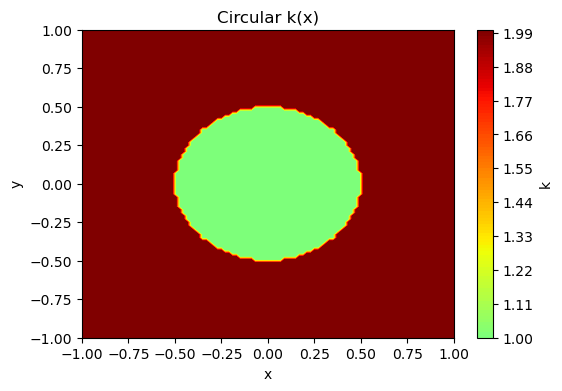

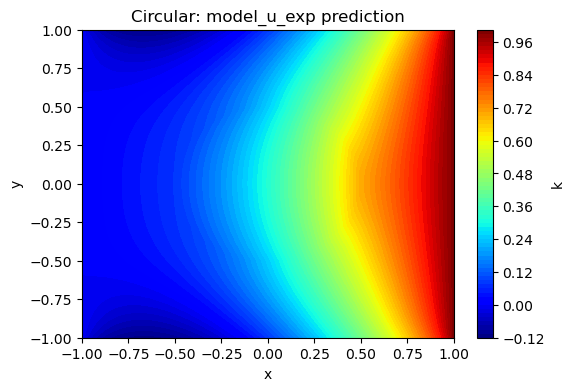

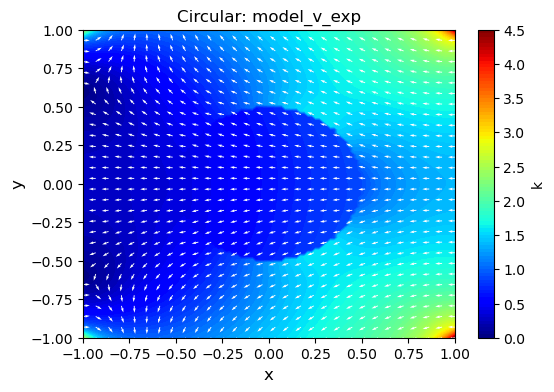

In [88]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=['Circular k(x)'],
    function_names=['k'],
    colour_map='jet',
    vmin=0,
    vmax=2,
    device=device,
    N=100,
    save_img=True,
)

plot_ctx.save_path = './images_moe_only_double/circular_k.png'
utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmin = -0.12
plot_ctx.vmax = 1
plot_ctx.titles = ['Circular: model_u_exp prediction']
plot_ctx.save_path = './images_moe_only_double/circular_u_pred.png'
utils.plot_function_on_2d_cube([lambda x: model_combined_exp(x)[:, 0]], plot_ctx)

plot_ctx.vmin = 0
plot_ctx.vmax = 4.5
plot_ctx.titles = ['Circular: model_v_exp']
plot_ctx.save_path = './images_moe_only_double/circular_v.png'
utils.plot_vector_field_2d([lambda x: model_combined_exp(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30)


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


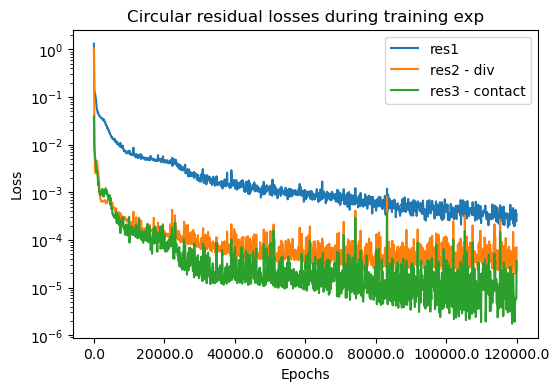

In [89]:
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'
plot_ctx.titles = ['Circular residual losses during training exp']
plot_ctx.save_path = './images_moe_only_double/circular_exp_losses.png'
utils.plot_loss_values({'res1': loss_comps_exp[0], 'res2 - div': loss_comps_exp[1], 'res3 - contact': loss_comps_exp[2]}, plot_ctx)


In [90]:
zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)

def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1
    return f

def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)
    return f

l2_r1 = L2_norm(make_res1_fn(model_combined_exp), zero_2d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
l2_r2 = L2_norm(make_res2_fn(model_combined_exp), zero_1d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
print(f'Circular MoE  L2 ||res1|| = {l2_r1.item():.6e},  L2 ||res2|| = {l2_r2.item():.6e}')


Circular MoE  L2 ||res1|| = 7.060438e-02,  L2 ||res2|| = 2.096485e-02


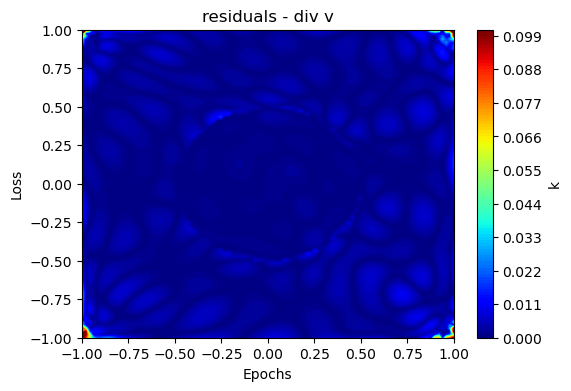

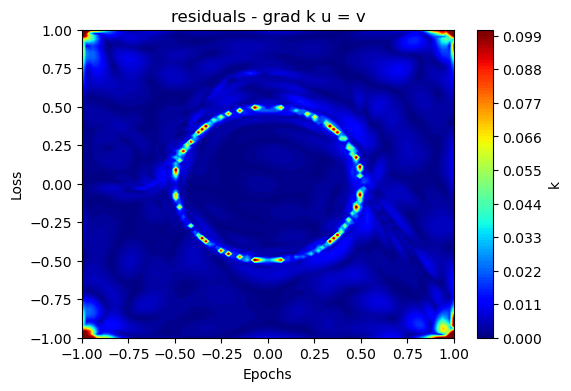

In [132]:
plot_ctx.vmax = 0.1

plot_ctx.titles = ["residuals - div v"]
plot_ctx.save_path = "./images_moe_only_double/model_v_res_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(make_res2_fn(model_combined_exp)(x)), 0.0, 0.1)], plot_ctx)

plot_ctx.titles = ["residuals - grad k u = v"]
plot_ctx.save_path = "./images_moe_only_double/model_v_res_equ.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.norm(make_res1_fn(model_combined_exp)(x), dim=1, p=2), 0.0, 0.1)], plot_ctx)

In [91]:
with h5py.File('darcy_solution.h5', 'r') as f:
    xy_np = f['samples/xy'][:]
    u_fem = f['samples/u_interp'][:]
    v_fem_np = f['samples/flux_interp'][:]

xy_fem = torch.tensor(xy_np, dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem, dtype=torch.float32, device=device)
v_fem_t = torch.tensor(v_fem_np, dtype=torch.float32, device=device)

with torch.no_grad():
    out = model_combined_exp(xy_fem)
    u_pred = out[:, 0]
    v_pred = out[:, 1:]

u_l2 = torch.linalg.vector_norm((u_pred - u_fem_t).abs(), ord=2)
u_rel_l2 = u_l2 / (torch.linalg.vector_norm(u_fem_t, ord=2) + 1e-12)
u_rmse = torch.sqrt(torch.mean((u_pred - u_fem_t)**2))

v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)
v_l2 = torch.linalg.vector_norm(v_err_mag, ord=2)
v_rel_l2 = v_l2 / (torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2) + 1e-12)
v_rmse = torch.sqrt(torch.mean((v_pred - v_fem_t)**2))

print(f'Circular MoE errors: u L2={u_l2.item():.4e}, u RelL2={u_rel_l2.item():.4e}, u RMSE={u_rmse.item():.4e}')
print(f'Circular MoE errors: v L2={v_l2.item():.4e}, v RelL2={v_rel_l2.item():.4e}, v RMSE={v_rmse.item():.4e}')


Circular MoE errors: u L2=2.2246e-01, u RelL2=4.8240e-03, u RMSE=2.2246e-03
Circular MoE errors: v L2=nan, v RelL2=nan, v RMSE=nan


In [117]:
def max_param_drift(model: torch.nn.Module, init_model: torch.nn.Module) -> float:
    learned = model.state_dict()
    initial = init_model.state_dict()
    return max((learned[k].float() - initial[k].float()).abs().max().item() for k in learned)

learned = model_combined_exp.state_dict()
initial = model_init_exp.state_dict()
deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
max_drift = max(d.max().item() for d in deltas)
mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)
print(f'Circular MoE max |Δ param| = {max_drift:.6e}')
print(f'Circular MoE mean |Δ param| = {mean_drift:.6e}')


Circular MoE max |Δ param| = 7.241162e+00
Circular MoE mean |Δ param| = 9.318217e-02


In [139]:
# ── Circular FEM comparison (similar to hard_dirichlet.ipynb) ─────────────────

with h5py.File('darcy_solution.h5', 'r') as f:
    xy_np = f['samples/xy'][:]          # (N, 2)
    u_fem = f['samples/u_interp'][:]    # (N,)
    v_fem_np = f['samples/flux_interp'][:]  # (N, 2)

xy_fem = torch.tensor(xy_np, dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem, dtype=torch.float32, device=device)
v_fem_t = torch.tensor(v_fem_np, dtype=torch.float32, device=device)

u_true_norm = torch.linalg.vector_norm(u_fem_t, ord=2)
v_true_norm = torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2)
vx_true_norm = torch.linalg.vector_norm(v_fem_t[:, 0], ord=2)
vy_true_norm = torch.linalg.vector_norm(v_fem_t[:, 1], ord=2)

model_combined_exp.eval()

with torch.no_grad():
    out = model_combined_exp(xy_fem)
    u_pred = out[:, 0]
    v_pred = out[:, 1:]
    
    u_err = (u_pred - u_fem_t).abs()
    u_l2 = torch.linalg.vector_norm(u_err, ord=2)
    u_rel_l2 = u_l2 / (u_true_norm + 1e-12)
    u_rmse = torch.sqrt(torch.mean((u_pred - u_fem_t)**2))

    v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)
    v_l2 = torch.linalg.vector_norm(v_err_mag, ord=2)
    v_rel_l2 = v_l2 / (v_true_norm + 1e-12)
    v_rmse = torch.sqrt(torch.mean((v_pred - v_fem_t)**2))

    vx_err = (v_pred[:, 0] - v_fem_t[:, 0]).abs()
    vx_l2 = torch.linalg.vector_norm(vx_err, ord=2)
    vx_rel_l2 = vx_l2 / (vx_true_norm + 1e-12)
    vx_rmse = torch.sqrt(torch.mean((v_pred[:, 0] - v_fem_t[:, 0])**2))

    vy_err = (v_pred[:, 1] - v_fem_t[:, 1]).abs()
    vy_l2 = torch.linalg.vector_norm(vy_err, ord=2)
    vy_rel_l2 = vy_l2 / (vy_true_norm + 1e-12)
    vy_rmse = torch.sqrt(torch.mean((v_pred[:, 1] - v_fem_t[:, 1])**2))


header = (
    f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
    f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
    f"  {'vx L2':>10}  {'vx RelL2':>10}  {'vx RMSE':>10}"
    f"  {'vy L2':>10}  {'vy RelL2':>10}  {'vy RMSE':>10}"
)

print(header)
print('-' * len(header))

print(
    f"{'combined_exp':<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}  {u_rmse.item():>10.4e}"
    f"  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}  {v_rmse.item():>10.4e}"
    f"  {vx_l2.item():>10.4e}  {vx_rel_l2.item():>10.4e}  {vx_rmse.item():>10.4e}"
    f"  {vy_l2.item():>10.4e}  {vy_rel_l2.item():>10.4e}  {vy_rmse.item():>10.4e}"
)

Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE       vx L2    vx RelL2     vx RMSE       vy L2    vy RelL2     vy RMSE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
combined_exp          2.2246e-01  4.8240e-03  2.2246e-03         nan         nan         nan         nan         nan         nan         nan         nan         nan


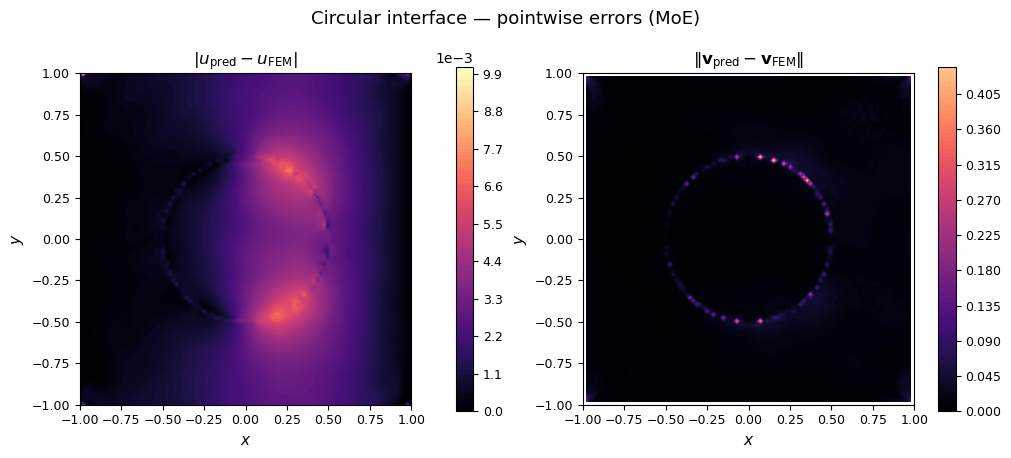

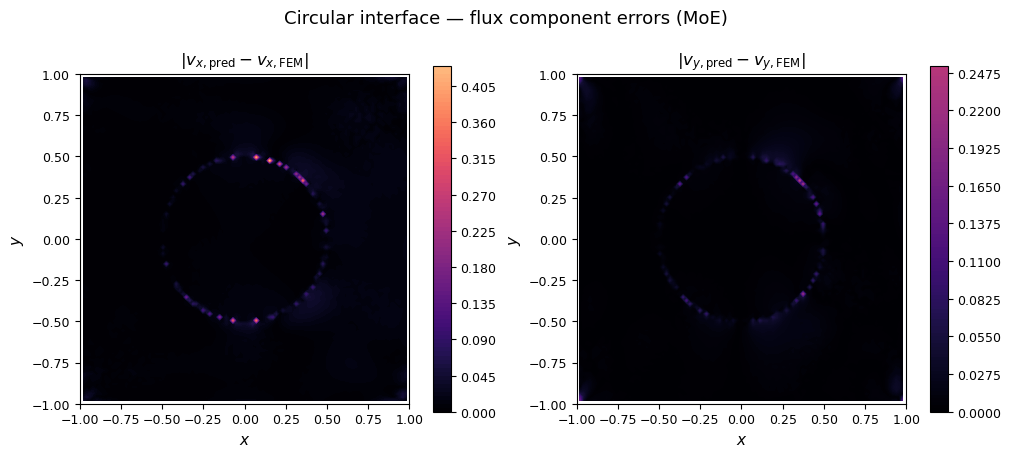

In [140]:
u_err_map = u_err.cpu().numpy()
v_err_map = v_err_mag.cpu().numpy()
vx_err_map = vx_err.cpu().numpy()
vy_err_map = vy_err.cpu().numpy()

# ── Shared styling constants ──────────────────────────────────────────────────
_LFS = 11   # axis label font size
_TFS = 12   # subplot title font size
_KFS = 9    # tick / colorbar font size

# ── Plot error maps: u and ||v|| ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

E = u_err_map.reshape(nx, ny)
c1 = axes[0].contourf(X, Y, E, levels=100, cmap='magma', vmin=0.0, vmax=0.01)
axes[0].set_title(r'$|u_{\mathrm{pred}} - u_{\mathrm{FEM}}|$', fontsize=_TFS)
axes[0].set_xlabel(r'$x$', fontsize=_LFS)
axes[0].set_ylabel(r'$y$', fontsize=_LFS)
axes[0].set_aspect('equal')
axes[0].tick_params(labelsize=_KFS)
cb1 = fig.colorbar(c1, ax=axes[0], shrink=0.85, pad=0.03)
cb1.ax.tick_params(labelsize=_KFS)
cb1.formatter.set_powerlimits((-2, 2))
cb1.update_ticks()

V = v_err_map.reshape(nx, ny)
c2 = axes[1].contourf(X, Y, V, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1].set_title(r'$\|\mathbf{v}_{\mathrm{pred}} - \mathbf{v}_{\mathrm{FEM}}\|$', fontsize=_TFS)
axes[1].set_xlabel(r'$x$', fontsize=_LFS)
axes[1].set_ylabel(r'$y$', fontsize=_LFS)
axes[1].set_aspect('equal')
axes[1].tick_params(labelsize=_KFS)
cb2 = fig.colorbar(c2, ax=axes[1], shrink=0.85, pad=0.03)
cb2.ax.tick_params(labelsize=_KFS)

fig.suptitle('Circular interface — pointwise errors (MoE)', fontsize=_TFS + 1)
plt.savefig('./images_moe_only_double/circular_model_errors_u.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Plot error maps: vx and vy components ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

Vx = vx_err_map.reshape(nx, ny)
c3 = axes[0].contourf(X, Y, Vx, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[0].set_title(r'$|v_{x,\mathrm{pred}} - v_{x,\mathrm{FEM}}|$', fontsize=_TFS)
axes[0].set_xlabel(r'$x$', fontsize=_LFS)
axes[0].set_ylabel(r'$y$', fontsize=_LFS)
axes[0].set_aspect('equal')
axes[0].tick_params(labelsize=_KFS)
cb3 = fig.colorbar(c3, ax=axes[0], shrink=0.85, pad=0.03)
cb3.ax.tick_params(labelsize=_KFS)

xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)


Vy = vy_err_map.reshape(nx, ny)
c4 = axes[1].contourf(X, Y, Vy, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1].set_title(r'$|v_{y,\mathrm{pred}} - v_{y,\mathrm{FEM}}|$', fontsize=_TFS)
axes[1].set_xlabel(r'$x$', fontsize=_LFS)
axes[1].set_ylabel(r'$y$', fontsize=_LFS)
axes[1].set_aspect('equal')
axes[1].tick_params(labelsize=_KFS)
cb4 = fig.colorbar(c4, ax=axes[1], shrink=0.85, pad=0.03)
cb4.ax.tick_params(labelsize=_KFS)

fig.suptitle('Circular interface — flux component errors (MoE)', fontsize=_TFS + 1)
plt.savefig('./images_moe_only_double/circular_model_errors_vcomps.png', dpi=200, bbox_inches='tight')
plt.show()

## Problem 2: Half-Square Interface (from hard_dirichlet_half_square)

We solve the half-square discontinuity problem and train only `model_combined_exp_hs`.


In [94]:
def k_hs(x: torch.Tensor) -> torch.Tensor:
    return torch.where(x[:, 0] < 0, 10.0, 1.0).unsqueeze(1)

def g_D_hs(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)

def u_0_hs(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2

def v_0_hs(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)

def h_hs(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

def res_hs(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]
    res_1 = k_hs(pde_in) * grad_u + v
    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]
    res_2 = v_1_x + v_2_y
    return res_1, res_2


In [95]:
def chi_hs(x):
    return torch.where(x[:, 0] < 0, 1.0, 0.0).float().unsqueeze(1)

model_ctx_u_hs = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[64, 64, 64],
    hard_enforce=True,
    constraint_functions=(g_D_hs, u_0_hs)
)

model_ctx_v_exp_hs = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[lambda x: 1 - chi_hs(x), chi_hs],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[32, 32, 32], [32, 32, 32]],
    hard_enforce=True,
    constraint_functions=(h_hs, v_0_hs),
)

model_u_exp_hs = mm.MLPModel(model_ctx_u_hs).to(device)
model_v_exp_hs = ec.PerCharModel(model_ctx_v_exp_hs).to(device)
model_combined_exp_hs = ec.MultiModel(model_u_exp_hs, model_v_exp_hs).to(device)

optim_combine_exp_hs = torch.optim.Adam(model_combined_exp_hs.parameters(), lr=5e-4)
sched_combine_exp_hs = ReduceLROnPlateau(optim_combine_exp_hs, factor=0.75, patience=2_000, min_lr=1e-6)


In [96]:
model_init_exp_hs = copy.deepcopy(model_combined_exp_hs)
print('Initial parameter snapshot saved for half-square MoE model.')


Initial parameter snapshot saved for half-square MoE model.


In [97]:
n_pts = 2000

bnd_cond = torch.column_stack([torch.zeros(n_pts), 2 * torch.rand(n_pts) - 1]).to(device)
n = torch.column_stack([torch.ones(n_pts), torch.zeros(n_pts)]).to(device)

def loss_combined_hs(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)
    pde_out = model(pde_in)
    
    u = pde_out[:, 0]
    v = pde_out[:, 1:]
    
    x_con = bnd_cond.detach().requires_grad_(True)
    v_1_cont = model.models[1].experts[0](x_con)
    v_2_cont = model.models[1].experts[1](x_con)

    flux_v_1 = torch.sum(v_1_cont * n, dim=1)
    flux_v_2 = torch.sum(v_2_cont * n, dim=1)
    cont_loss = torch.mean((flux_v_1 - flux_v_2)**2)
    
    res_1, res_2 = res_hs(u, v, pde_in)
    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2
    
    loss_1 = torch.mean(res_sq)
    loss_2 = torch.mean(res_2**2)
    return [loss_1, loss_2, cont_loss]


In [98]:
domain_ctx_hs = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain_hs = cb.CubeDomain(domain_ctx_hs)
print(f'Half-square interior points: {domain_hs.interior.shape}')


Half-square interior points: torch.Size([10000, 2])


In [99]:
train_ctx_combined_hs = train.TrainingContext(
    model=model_combined_exp_hs,
    domain=domain_hs,
    optimizer=optim_combine_exp_hs,
    loss_fn=loss_combined_hs,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp_hs, loss_comps_exp_hs = train.train_switch_to_lbfgs(
    train_ctx_combined_hs, lbfgs_lr=0.1, epochs_with_lbfgs=1_000
)


Loss at epoch 1 is: 13.174964904785156. Total gradient norm: nan Current learing rate: 0.0005 
Loss at epoch 100 is: 0.4763520359992981. Total gradient norm: 0.7991500417146301 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.31835243105888367. Total gradient norm: 0.2604610646293638 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.28413891792297363. Total gradient norm: 0.07001417481654781 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.275431364774704. Total gradient norm: 0.09793951057987821 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.26272740960121155. Total gradient norm: 0.06143206269731019 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.25072166323661804. Total gradient norm: 0.11868534408781911 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.23669588565826416. Total gradient norm: 0.1191265139005761 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.2073780745267868. Total gradient norm: 0.1397828311775659 Current learing rate: 0.0005 
L

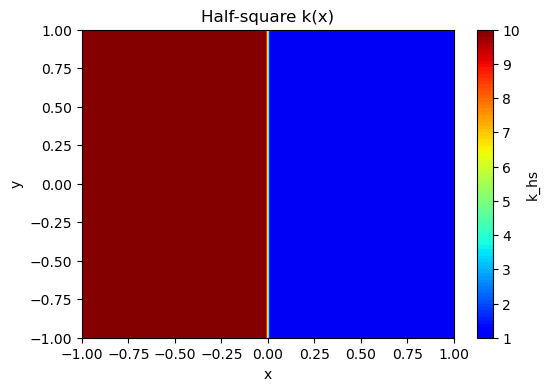

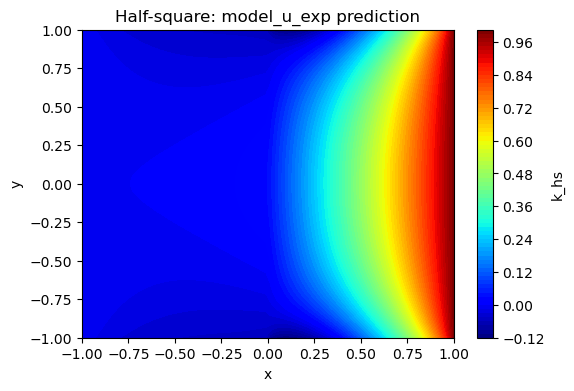

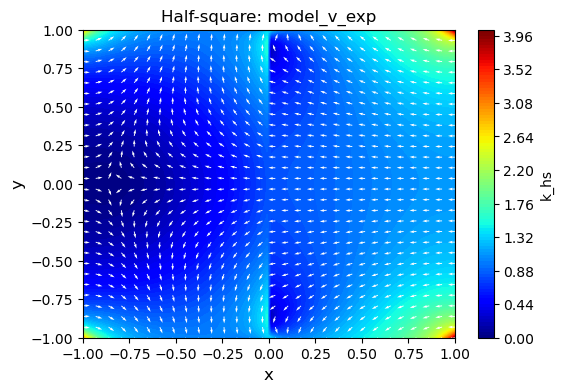

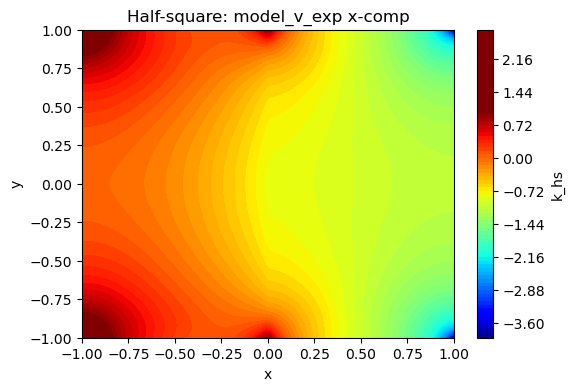

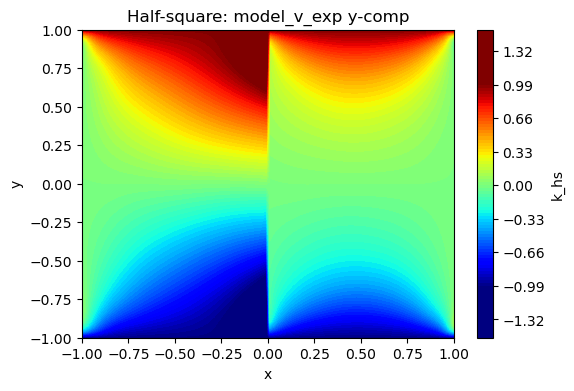

In [100]:
plot_ctx_hs = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=['Half-square k(x)'],
    function_names=['k_hs'],
    colour_map='jet',
    vmin=0,
    vmax=10,
    device=device,
    N=100,
    save_img=True,
)

plot_ctx_hs.save_path = './images_moe_only_double/half_square_k.png'
utils.plot_function_on_2d_cube([k_hs], plot_ctx_hs)

plot_ctx_hs.vmin = -0.12
plot_ctx_hs.vmax = 1
plot_ctx_hs.titles = ['Half-square: model_u_exp prediction']
plot_ctx_hs.save_path = './images_moe_only_double/half_square_u_pred.png'
utils.plot_function_on_2d_cube([lambda x: model_combined_exp_hs(x)[:, 0]], plot_ctx_hs)

plot_ctx_hs.vmin = 0
plot_ctx_hs.vmax = 4
plot_ctx_hs.titles = ['Half-square: model_v_exp']
plot_ctx_hs.save_path = './images_moe_only_double/half_square_v.png'
utils.plot_vector_field_2d([lambda x: model_combined_exp_hs(x)[:, 1:]], plot_ctx_hs, N=100, n_heigth=30, n_width=30)


plot_ctx_hs.vmin = -4
plot_ctx_hs.vmax = 1
plot_ctx_hs.titles = ['Half-square: model_v_exp x-comp']
plot_ctx_hs.save_path = './images_moe_only_double/half_square_v_x_comp.png'
utils.plot_function_on_2d_cube([lambda x: model_combined_exp_hs(x)[:, 1]], plot_ctx_hs)


plot_ctx_hs.vmin = -1
plot_ctx_hs.vmax = 1
plot_ctx_hs.titles = ['Half-square: model_v_exp y-comp']
plot_ctx_hs.save_path = './images_moe_only_double/half_square_v_y_comp.png'
utils.plot_function_on_2d_cube([lambda x: model_combined_exp_hs(x)[:, 2]], plot_ctx_hs)


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


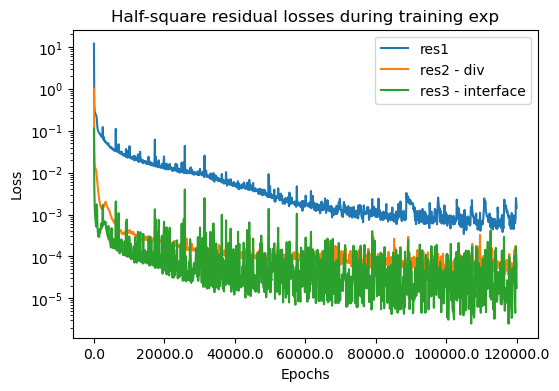

In [101]:
plot_ctx_hs.y_label = 'Loss'
plot_ctx_hs.x_label = 'Epochs'
plot_ctx_hs.titles = ['Half-square residual losses during training exp']
plot_ctx_hs.save_path = './images_moe_only_double/half_square_exp_losses.png'
utils.plot_loss_values({'res1': loss_comps_exp_hs[0], 'res2 - div': loss_comps_exp_hs[1], 'res3 - interface': loss_comps_exp_hs[2]},plot_ctx_hs)


In [102]:
def make_res1_fn_hs(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res_hs(u, v, x)
        return r1
    return f

def make_res2_fn_hs(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res_hs(u, v, x)
        return r2.unsqueeze(1)
    return f

l2_r1_hs = L2_norm(make_res1_fn_hs(model_combined_exp_hs), zero_2d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
l2_r2_hs = L2_norm(make_res2_fn_hs(model_combined_exp_hs), zero_1d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
print(f'Half-square MoE  L2 ||res1|| = {l2_r1_hs.item():.6e},  L2 ||res2|| = {l2_r2_hs.item():.6e}')


Half-square MoE  L2 ||res1|| = 3.731602e-02,  L2 ||res2|| = 1.449406e-02


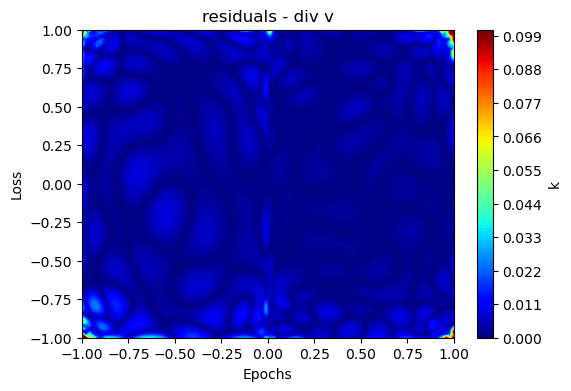

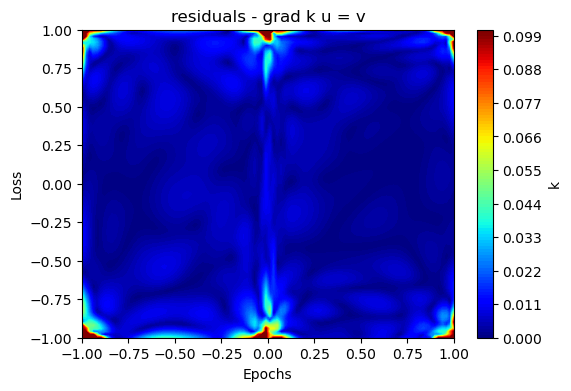

In [131]:
plot_ctx.vmax = 0.1

plot_ctx.titles = ["residuals - div v"]
plot_ctx.save_path = "./images_moe_only_double/model_v_res_div_hs.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(make_res2_fn_hs(model_combined_exp_hs)(x)), 0.0, 0.1)], plot_ctx)

plot_ctx.titles = ["residuals - grad k u = v"]
plot_ctx.save_path = "./images_moe_only_double/model_v_res_equ_hs.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.norm(make_res1_fn_hs(model_combined_exp_hs)(x), dim=1, p=2), 0.0, 0.1)], plot_ctx)

In [103]:
with h5py.File('darcy_half_square_solution.h5', 'r') as f:
    xy_np_hs = f['samples/xy'][:]
    u_fem_hs = f['samples/u_interp'][:]
    v_fem_np_hs = f['samples/flux_interp'][:]

xy_fem_hs = torch.tensor(xy_np_hs, dtype=torch.float32, device=device)
u_fem_t_hs = torch.tensor(u_fem_hs, dtype=torch.float32, device=device)
v_fem_t_hs = torch.tensor(v_fem_np_hs, dtype=torch.float32, device=device)

with torch.no_grad():
    out_hs = model_combined_exp_hs(xy_fem_hs)
    u_pred_hs = out_hs[:, 0]
    v_pred_hs = out_hs[:, 1:]

u_l2_hs = torch.linalg.vector_norm((u_pred_hs - u_fem_t_hs).abs(), ord=2)
u_rel_l2_hs = u_l2_hs / (torch.linalg.vector_norm(u_fem_t_hs, ord=2) + 1e-12)
u_rmse_hs = torch.sqrt(torch.mean((u_pred_hs - u_fem_t_hs)**2))

v_err_mag_hs = torch.norm(v_pred_hs - v_fem_t_hs, dim=1, p=2)
v_l2_hs = torch.linalg.vector_norm(v_err_mag_hs, ord=2)
v_rel_l2_hs = v_l2_hs / (torch.linalg.vector_norm(v_fem_t_hs.reshape(-1), ord=2) + 1e-12)
v_rmse_hs = torch.sqrt(torch.mean((v_pred_hs - v_fem_t_hs)**2))

print(f'Half-square MoE errors: u L2={u_l2_hs.item():.4e}, u RelL2={u_rel_l2_hs.item():.4e}, u RMSE={u_rmse_hs.item():.4e}')
print(f'Half-square MoE errors: v L2={v_l2_hs.item():.4e}, v RelL2={v_rel_l2_hs.item():.4e}, v RMSE={v_rmse_hs.item():.4e}')


Half-square MoE errors: u L2=4.7244e-02, u RelL2=1.2836e-03, u RMSE=4.7244e-04
Half-square MoE errors: v L2=nan, v RelL2=nan, v RMSE=nan


Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE       vx L2    vx RelL2     vx RMSE       vy L2    vy RelL2     vy RMSE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
combined_exp_hs       4.7244e-02  1.2836e-03  4.7244e-04         nan         nan         nan         nan         nan         nan         nan         nan         nan


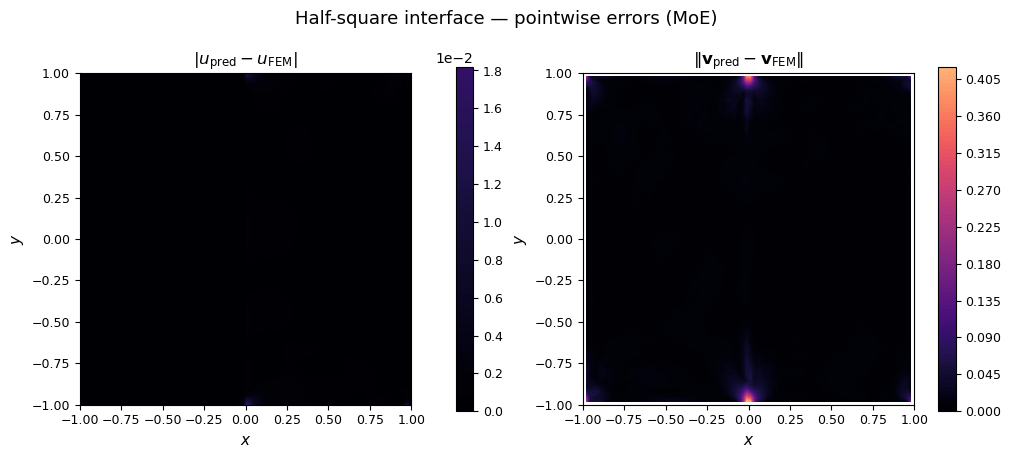

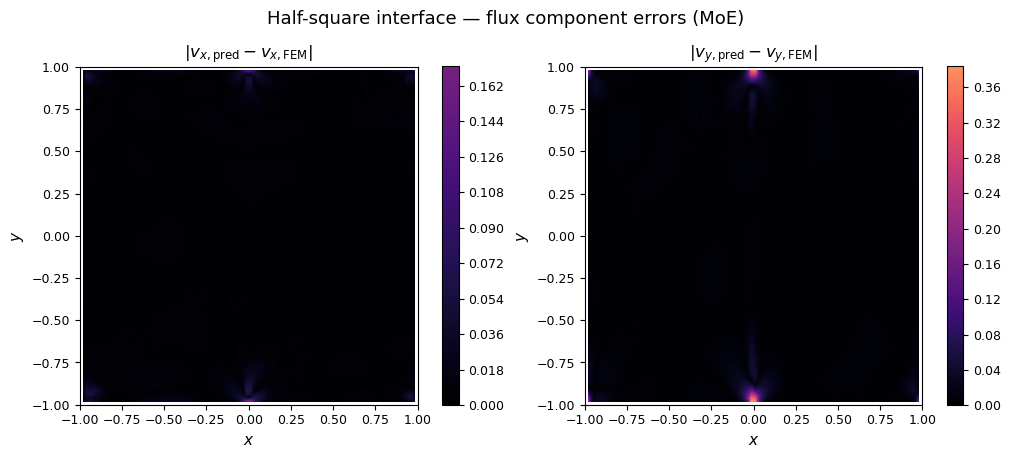

Saved half-square FEM comparison plots.


In [ ]:
# ── Half-square FEM comparison (same style as hard_dirichlet.ipynb) ───────────
with h5py.File('darcy_half_square_solution.h5', 'r') as f:
    xy_np_hs = f['samples/xy'][:]
    u_fem_hs = f['samples/u_interp'][:]
    v_fem_np_hs = f['samples/flux_interp'][:]

xy_fem_hs = torch.tensor(xy_np_hs, dtype=torch.float32, device=device)
u_fem_t_hs = torch.tensor(u_fem_hs, dtype=torch.float32, device=device)
v_fem_t_hs = torch.tensor(v_fem_np_hs, dtype=torch.float32, device=device)

u_true_norm_hs = torch.linalg.vector_norm(u_fem_t_hs, ord=2)
v_true_norm_hs = torch.linalg.vector_norm(v_fem_t_hs.reshape(-1), ord=2)
vx_true_norm_hs = torch.linalg.vector_norm(v_fem_t_hs[:, 0], ord=2)
vy_true_norm_hs = torch.linalg.vector_norm(v_fem_t_hs[:, 1], ord=2)

model_name = 'combined_exp_hs'
model_combined_exp_hs.eval()
with torch.no_grad():
    out_hs = model_combined_exp_hs(xy_fem_hs)
    u_pred_hs = out_hs[:, 0]
    v_pred_hs = out_hs[:, 1:]

    u_err = (u_pred_hs - u_fem_t_hs).abs()
    u_l2 = torch.linalg.vector_norm(u_err, ord=2)
    u_rel_l2 = u_l2 / (u_true_norm_hs + 1e-12)
    u_rmse = torch.sqrt(torch.mean((u_pred_hs - u_fem_t_hs)**2))

    v_err_mag = torch.norm(v_pred_hs - v_fem_t_hs, dim=1, p=2)
    v_l2 = torch.linalg.vector_norm(v_err_mag, ord=2)
    v_rel_l2 = v_l2 / (v_true_norm_hs + 1e-12)
    v_rmse = torch.sqrt(torch.mean((v_pred_hs - v_fem_t_hs)**2))

    vx_err = (v_pred_hs[:, 0] - v_fem_t_hs[:, 0]).abs()
    vx_l2 = torch.linalg.vector_norm(vx_err, ord=2)
    vx_rel_l2 = vx_l2 / (vx_true_norm_hs + 1e-12)
    vx_rmse = torch.sqrt(torch.mean((v_pred_hs[:, 0] - v_fem_t_hs[:, 0])**2))

    vy_err = (v_pred_hs[:, 1] - v_fem_t_hs[:, 1]).abs()
    vy_l2 = torch.linalg.vector_norm(vy_err, ord=2)
    vy_rel_l2 = vy_l2 / (vy_true_norm_hs + 1e-12)
    vy_rmse = torch.sqrt(torch.mean((v_pred_hs[:, 1] - v_fem_t_hs[:, 1])**2))

header = (
    f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
    f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
    f"  {'vx L2':>10}  {'vx RelL2':>10}  {'vx RMSE':>10}"
    f"  {'vy L2':>10}  {'vy RelL2':>10}  {'vy RMSE':>10}"
)
print(header)
print('-' * len(header))
print(
    f"{model_name:<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}  {u_rmse.item():>10.4e}"
    f"  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}  {v_rmse.item():>10.4e}"
    f"  {vx_l2.item():>10.4e}  {vx_rel_l2.item():>10.4e}  {vx_rmse.item():>10.4e}"
    f"  {vy_l2.item():>10.4e}  {vy_rel_l2.item():>10.4e}  {vy_rmse.item():>10.4e}"
)

In [ ]:
u_err_map = u_err.cpu().numpy()
v_err_map = v_err_mag.cpu().numpy()
vx_err_map = vx_err.cpu().numpy()
vy_err_map = vy_err.cpu().numpy()

# ── Shared styling constants ──────────────────────────────────────────────────
_LFS = 11
_TFS = 12
_KFS = 9

xs = np.unique(xy_np_hs[:, 0])
ys = np.unique(xy_np_hs[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np_hs[:, 0].reshape(nx, ny)
Y = xy_np_hs[:, 1].reshape(nx, ny)

# ── Plot error maps: u and ||v|| ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

E = u_err_map.reshape(nx, ny)
c1 = axes[0].contourf(X, Y, E, levels=100, cmap='magma', vmin=0.0, vmax=0.1)
axes[0].set_title(r'$|u_{\mathrm{pred}} - u_{\mathrm{FEM}}|$', fontsize=_TFS)
axes[0].set_xlabel(r'$x$', fontsize=_LFS)
axes[0].set_ylabel(r'$y$', fontsize=_LFS)
axes[0].set_aspect('equal')
axes[0].tick_params(labelsize=_KFS)
cb1 = fig.colorbar(c1, ax=axes[0], shrink=0.85, pad=0.03)
cb1.ax.tick_params(labelsize=_KFS)
cb1.formatter.set_powerlimits((-2, 2))
cb1.update_ticks()

V = v_err_map.reshape(nx, ny)
c2 = axes[1].contourf(X, Y, V, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1].set_title(r'$\|\mathbf{v}_{\mathrm{pred}} - \mathbf{v}_{\mathrm{FEM}}\|$', fontsize=_TFS)
axes[1].set_xlabel(r'$x$', fontsize=_LFS)
axes[1].set_ylabel(r'$y$', fontsize=_LFS)
axes[1].set_aspect('equal')
axes[1].tick_params(labelsize=_KFS)
cb2 = fig.colorbar(c2, ax=axes[1], shrink=0.85, pad=0.03)
cb2.ax.tick_params(labelsize=_KFS)

fig.suptitle('Half-square interface — pointwise errors (MoE)', fontsize=_TFS + 1)
plt.savefig('./images_moe_only_double/half_square_model_errors_u.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Plot error maps: vx and vy components ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

Vx = vx_err_map.reshape(nx, ny)
c3 = axes[0].contourf(X, Y, Vx, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[0].set_title(r'$|v_{x,\mathrm{pred}} - v_{x,\mathrm{FEM}}|$', fontsize=_TFS)
axes[0].set_xlabel(r'$x$', fontsize=_LFS)
axes[0].set_ylabel(r'$y$', fontsize=_LFS)
axes[0].set_aspect('equal')
axes[0].tick_params(labelsize=_KFS)
cb3 = fig.colorbar(c3, ax=axes[0], shrink=0.85, pad=0.03)
cb3.ax.tick_params(labelsize=_KFS)

Vy = vy_err_map.reshape(nx, ny)
c4 = axes[1].contourf(X, Y, Vy, levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1].set_title(r'$|v_{y,\mathrm{pred}} - v_{y,\mathrm{FEM}}|$', fontsize=_TFS)
axes[1].set_xlabel(r'$x$', fontsize=_LFS)
axes[1].set_ylabel(r'$y$', fontsize=_LFS)
axes[1].set_aspect('equal')
axes[1].tick_params(labelsize=_KFS)
cb4 = fig.colorbar(c4, ax=axes[1], shrink=0.85, pad=0.03)
cb4.ax.tick_params(labelsize=_KFS)

fig.suptitle('Half-square interface — flux component errors (MoE)', fontsize=_TFS + 1)
plt.savefig('./images_moe_only_double/half_square_model_errors_vcomps.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved half-square FEM comparison plots.')


In [105]:
pairs_hs = {'combined_exp_hs': (model_combined_exp_hs, model_init_exp_hs)}
print(f"{'Model':<20}  {'Max |Δ param|':>14}  {'Mean |Δ param|':>15}")
print('-' * 54)
for name, (trained, init) in pairs_hs.items():
    learned = trained.state_dict()
    initial = init.state_dict()
    deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
    max_drift = max(d.max().item() for d in deltas)
    mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)
    print(f'{name:<20}  {max_drift:>14.6e}  {mean_drift:>15.6e}')


Model                  Max |Δ param|   Mean |Δ param|
------------------------------------------------------
combined_exp_hs         1.072496e+01     1.047576e-01


In [106]:
# Transmission condition check (same style as half-square reference)
K_1 = 10.0
K_2 = 1.0
RATIO = K_1 / K_2
eps = 1e-4
N_pts = 400

y_vals = torch.linspace(-1.0 + 1e-3, 1.0 - 1e-3, N_pts, device=device)
x_right = torch.stack([torch.full_like(y_vals, eps), y_vals], dim=1)
x_left = torch.stack([torch.full_like(y_vals, -eps), y_vals], dim=1)

model_combined_exp_hs.eval()
with torch.no_grad():
    v_r = model_combined_exp_hs(x_right)[:, 1:]
    v_l = model_combined_exp_hs(x_left)[:, 1:]

diff_x = (v_l[:, 0] - RATIO * v_r[:, 0]).abs()
diff_y = (v_l[:, 1] - RATIO * v_r[:, 1]).abs()
print(f'Transmission check (MoE only): mean|Δvx|={diff_x.mean().item():.4e}, max|Δvx|={diff_x.max().item():.4e}')
print(f'Transmission check (MoE only): mean|Δvy|={diff_y.mean().item():.4e}, max|Δvy|={diff_y.max().item():.4e}')


Transmission check (MoE only): mean|Δvx|=5.4890e+00, max|Δvx|=9.1931e+00
Transmission check (MoE only): mean|Δvy|=5.4825e-01, max|Δvy|=8.8703e+00
